# Student Cost of Living in Prague
## Data Processing in Python 
Anna Chodurková, Barbora Motyková

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from IPython.display import display, Math

In [3]:
from source_code.cost_model import build_scenario_table, compute_monthly_cost

In [4]:
df=build_scenario_table(canteen_days=5)
df

,housing,canteen,groceries,transport,leisure,total,type
label,,,,,,,
Dorm 1-bed (shared facilities),6120.000000,2520.8,1043.68,106.666667,2000,11791.146667,dorm
Dorm 1-bed (own facilities),8035.000000,2520.8,1043.68,106.666667,2000,13706.146667,dorm
Dorm 2-bed (shared facilities),4815.000000,2520.8,1043.68,106.666667,2000,10486.146667,dorm
Dorm 2-bed (own facilities),5910.000000,2520.8,1043.68,106.666667,2000,11581.146667,dorm
Dorm 3-bed (shared facilities),4087.500000,2520.8,1043.68,106.666667,2000,9758.646667,dorm
Dorm 3-bed (own facilities),3975.000000,2520.8,1043.68,106.666667,2000,9646.146667,dorm
Dorm 4-bed (shared facilities),3765.000000,2520.8,1043.68,106.666667,2000,9436.146667,dorm
Flat 1+KK center,25472.857143,2520.8,1043.68,106.666667,2000,31144.003810,apartment
Flat 2+KK center,16175.625000,2520.8,1043.68,106.666667,2000,21846.771667,apartment


In [5]:
df_sorted = df.sort_values("total")
df_sorted

,housing,canteen,groceries,transport,leisure,total,type
label,,,,,,,
Dorm 4-bed (shared facilities),3765.000000,2520.8,1043.68,106.666667,2000,9436.146667,dorm
Dorm 3-bed (own facilities),3975.000000,2520.8,1043.68,106.666667,2000,9646.146667,dorm
Dorm 3-bed (shared facilities),4087.500000,2520.8,1043.68,106.666667,2000,9758.646667,dorm
Dorm 2-bed (shared facilities),4815.000000,2520.8,1043.68,106.666667,2000,10486.146667,dorm
Dorm 2-bed (own facilities),5910.000000,2520.8,1043.68,106.666667,2000,11581.146667,dorm
Dorm 1-bed (shared facilities),6120.000000,2520.8,1043.68,106.666667,2000,11791.146667,dorm
Dorm 1-bed (own facilities),8035.000000,2520.8,1043.68,106.666667,2000,13706.146667,dorm
Flat 3+KK outer_or_suburbs,10536.373333,2520.8,1043.68,106.666667,2000,16207.520000,apartment
Flat 3+KK inner_city,11940.160256,2520.8,1043.68,106.666667,2000,17611.306923,apartment


<Axes: ylabel='label'>

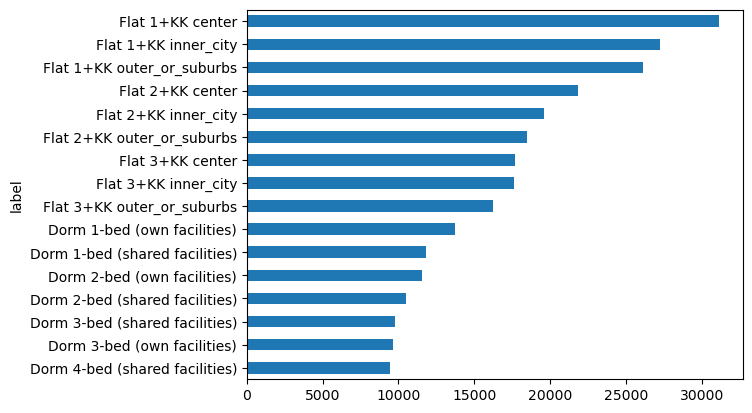

In [6]:
df_sorted["total"].plot.barh()

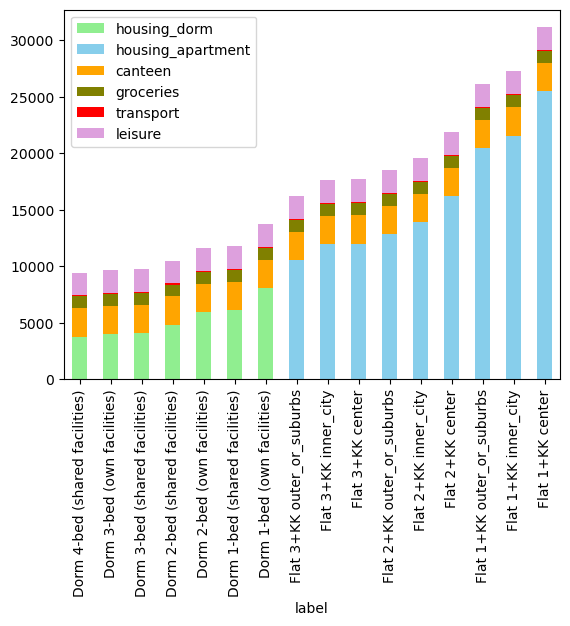

In [7]:
parts=["housing_dorm","housing_apartment","canteen","groceries","transport","leisure"]

df_sorted["housing_dorm"] =df_sorted["housing"].where(df_sorted["type"]=="dorm", 0)
df_sorted["housing_apartment"] =df_sorted["housing"].where(df_sorted["type"]=="apartment", 0)

colors={
    "housing_dorm":"lightgreen",
    "housing_apartment":"skyblue",
    "canteen":"orange",
    "groceries":"olive",
    "transport":"red",
    "leisure":"plum"}

df_sorted[parts].plot.bar(stacked=True,color=[colors[p]for p in parts])
plt.savefig("figures/total_costs.png",bbox_inches="tight")
plt.show()

In [8]:
os.getcwd()

'c:\\Users\\chodu\\Desktop\\midterm2026\\project'

# Housing analysis 


In [9]:
patha = os.getcwd()
patha = os.path.join(patha, "data", "clean", "apartments_clean.csv")

apartments = pd.read_csv(patha)

In [10]:
pathds = os.getcwd()
pathds = os.path.join(pathds, "data", "clean", "district_stats.csv")

district_stats = pd.read_csv(pathds)

In [11]:
pathd = os.getcwd()
pathd = os.path.join(pathd, "data", "clean", "dorm_stats.csv")

dorms = pd.read_csv(pathd)

In [12]:
district_stats

,zone,disposition_clean,avg_rent,avg_m2_price,count
0,center,1+1,22566.666667,687.672533,3
1,center,1+KK,25472.857143,976.291126,7
2,center,2+1,32422.222222,493.355657,9
3,center,2+KK,32351.250000,718.018330,8
4,center,3+1,35800.000000,421.176471,1
5,center,3+KK,36000.000000,500.000000,3
6,center,unknown,45610.200000,1390.823892,15
7,inner_city,1+1,21398.333333,545.719975,36
8,inner_city,1+KK,21562.980892,706.096441,157
9,inner_city,2+1,27749.073171,469.820999,82


### 1. How affordable are apartments in Prague?

In [13]:
#create price categories
bins = [0,15000,25000,35000,60000]
labels=["very_cheap", "lower_student", "upper_student", "luxury"]

apartments["price_group"] = pd.cut(
    apartments["full_cost"],
    bins=bins,
    labels=labels)

In [14]:
apartments["price_group"].value_counts(normalize=True)*100
#only 4% of apartments fall into very cheap category (under 15000)
#majority of appartments fall into the lower_student and upper_student categories

price_group
upper_student    39.967506
lower_student    38.830219
luxury           17.140536
very_cheap        4.061738
Name: proportion, dtype: float64

In [15]:
apartments["full_cost"].sort_values()

148      7500
557      8750
760     10000
1135    10401
839     10500
        ...  
954     58990
1050    59000
632     59275
18      59487
114     59609
Name: full_cost, Length: 1231, dtype: int64

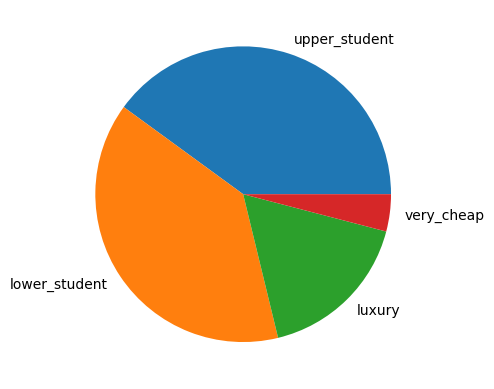

In [16]:
counts=apartments["price_group"].value_counts()
plt.pie(counts,labels=counts.index)
plt.show()

1.
Only 4% of apartments fall into very cheap category (under 15000)   
Majority of appartments fall into the lower_student and upper_student categories

### 2. Does location affect apartment prices?

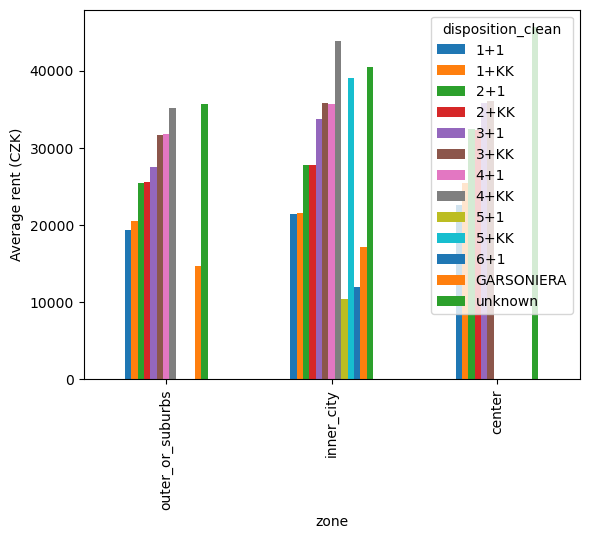

In [17]:
pivot = district_stats.pivot(index="zone", columns="disposition_clean", values="avg_rent")

# sort rows by overall average rent across zones
pivot = pivot.loc[pivot.mean(axis=1).sort_values().index]

pivot.plot.bar()

plt.ylabel("Average rent (CZK)")
plt.show()

In [18]:
pd.crosstab(apartments["zone"],apartments["price_group"],normalize="index")

price_group,very_cheap,lower_student,upper_student,luxury
zone,,,,
center,0.000000,0.108696,0.478261,0.413043
inner_city,0.034621,0.347537,0.415446,0.202397
outer_or_suburbs,0.055300,0.488479,0.364055,0.092166


2.  
Luxury and upper_student apartments are concentrated in the center   
Outer districs contain a larger proportion of affordable housing 

### 3. Which apartment type provides the best value?

In [19]:
district_stats.sort_values("avg_m2_price")[["zone", "disposition_clean", "avg_m2_price"]]


,zone,disposition_clean,avg_m2_price
17,inner_city,6+1,92.307692
15,inner_city,5+1,122.364706
26,outer_or_suburbs,4+1,302.726352
27,outer_or_suburbs,4+KK,334.415775
24,outer_or_suburbs,3+1,349.010886
13,inner_city,4+1,383.336364
11,inner_city,3+1,403.396254
4,center,3+1,421.176471
25,outer_or_suburbs,3+KK,425.715397
14,inner_city,4+KK,432.319556


In [20]:
zone_means = district_stats.groupby("zone")["avg_m2_price"].mean()
zone_effect = zone_means.var()
size_means = district_stats.groupby("disposition_clean")["avg_m2_price"].mean()
size_effect = size_means.var()
print(f"Zone effect: {zone_effect} \nSize effect: {size_effect}")


Zone effect: 19640.596116703622 
Size effect: 72549.85880830267


In [21]:
print("Zone effect:", zone_effect)
print("Size effect:", size_effect)

Zone effect: 19640.596116703622
Size effect: 72549.85880830267


3.1 Apartment size/layout matters more than location for price per m2

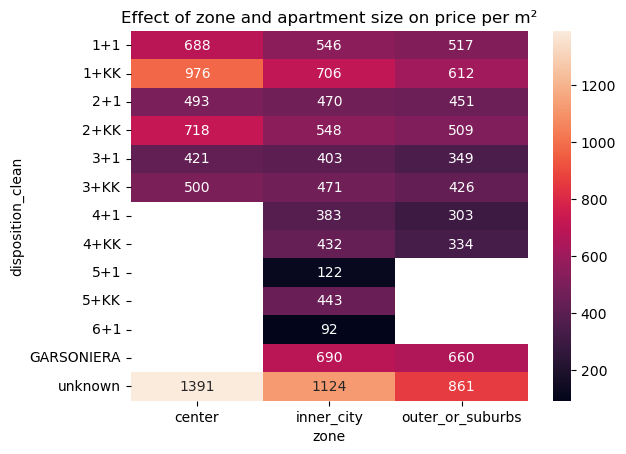

In [22]:
pivot = district_stats.pivot(
    index="disposition_clean",
    columns="zone",
    values="avg_m2_price"
)

sns.heatmap(pivot,annot=True,fmt=".0f")
plt.title("Effect of zone and apartment size on price per m²")
plt.show()

3.2   
Apartments in the center have higher prices, while suburban areas are cheaper  

Smaller apartments are signigicantly more expensive per m2 than larger apartments, regrdless of location

interaction effect:   
Small apartments benefit more from central location   
Large apartments lose value efficiency even in good location

### 4. Is sharing accommodation worthwhile?

In [23]:
apartments

,price,charges,surface,disposition,address,district,full_cost,disposition_clean,price_per_m2,zone,price_group
0,16100,3100,33,DISP_1_KK,"Federova, Praha - Kyje",Kyje,19200,1+KK,581.818182,outer_or_suburbs,lower_student
1,40621,7168,40,NaN,"Starokošířská, Praha - Košíře",Košíře,47789,unknown,1194.725000,inner_city,luxury
2,28000,6000,80,DISP_3_KK,"Amforova, Praha - Stodůlky",Stodůlky,34000,3+KK,425.000000,outer_or_suburbs,upper_student
3,15990,0,33,DISP_1_KK,"Freyova, Praha - Vysočany",Vysočany,15990,1+KK,484.545455,inner_city,lower_student
4,24500,3000,51,DISP_2_1,"náměstí Josefa Machka, Praha - Košíře",Košíře,27500,2+1,539.215686,inner_city,upper_student
...,...,...,...,...,...,...,...,...,...,...,...
1226,34900,12049,71,DISP_3_1,"Francouzská, Praha - Vinohrady",Vinohrady,46949,3+1,661.253521,inner_city,luxury
1227,31987,5645,31,NaN,"Kmochova, Praha - Smíchov",Smíchov,37632,unknown,1213.935484,inner_city,luxury
1228,23000,4000,42,DISP_2_KK,"Podplukovníka Sochora, Praha - Holešovice",Holešovice,27000,2+KK,642.857143,inner_city,upper_student
1229,19000,3500,43,DISP_2_KK,"Nad Kolonií, Praha - Podolí",Podolí,22500,2+KK,523.255814,inner_city,lower_student


In [24]:
sharing=apartments[apartments["disposition_clean"]!="unknown"].copy()

sharing["people"]=(
    sharing["disposition_clean"]
    .replace("GARSONIERA","1+KK")
    .str.split("+").str[0].astype(int)
)

In [25]:
sharing

,price,charges,surface,disposition,address,district,full_cost,disposition_clean,price_per_m2,zone,price_group,people
0,16100,3100,33,DISP_1_KK,"Federova, Praha - Kyje",Kyje,19200,1+KK,581.818182,outer_or_suburbs,lower_student,1
2,28000,6000,80,DISP_3_KK,"Amforova, Praha - Stodůlky",Stodůlky,34000,3+KK,425.000000,outer_or_suburbs,upper_student,3
3,15990,0,33,DISP_1_KK,"Freyova, Praha - Vysočany",Vysočany,15990,1+KK,484.545455,inner_city,lower_student,1
4,24500,3000,51,DISP_2_1,"náměstí Josefa Machka, Praha - Košíře",Košíře,27500,2+1,539.215686,inner_city,upper_student,2
6,14990,0,45,DISP_2_KK,"Donská, Praha - Vršovice",Vršovice,14990,2+KK,333.111111,inner_city,very_cheap,2
...,...,...,...,...,...,...,...,...,...,...,...,...
1225,21000,3000,41,DISP_2_KK,"Vorařská, Praha - Modřany",Modřany,24000,2+KK,585.365854,outer_or_suburbs,lower_student,2
1226,34900,12049,71,DISP_3_1,"Francouzská, Praha - Vinohrady",Vinohrady,46949,3+1,661.253521,inner_city,luxury,3
1228,23000,4000,42,DISP_2_KK,"Podplukovníka Sochora, Praha - Holešovice",Holešovice,27000,2+KK,642.857143,inner_city,upper_student,2
1229,19000,3500,43,DISP_2_KK,"Nad Kolonií, Praha - Podolí",Podolí,22500,2+KK,523.255814,inner_city,lower_student,2


In [26]:
sharing["price_per_person"]=sharing["full_cost"]/sharing["people"]

In [27]:
groups=sharing.groupby("people")["price_per_person"].mean()
groups

people
1    20848.036723
2    13584.274225
3    10912.089820
4     9597.342593
5     4940.100000
6     2000.000000
Name: price_per_person, dtype: float64

In [28]:
baseline=groups.loc[1]

savings=baseline-groups
savings_pct=(savings/baseline)*100

In [29]:
sharing_stats=pd.DataFrame({
    "avg_cost_per_person":groups,
    "savings_czk": savings,
    "savings_pct": savings_pct
})
sharing_stats

,avg_cost_per_person,savings_czk,savings_pct
people,,,
1,20848.036723,0.000000,0.000000
2,13584.274225,7263.762498,34.841470
3,10912.089820,9935.946903,47.658909
4,9597.342593,11250.694131,53.965245
5,4940.100000,15907.936723,76.304244
6,2000.000000,18848.036723,90.406771


$$
\text{Total savings} =
\frac{cost_{\text{alone}} - cost_{\text{group}}}{cost_{\text{alone}}} \times 100
$$

$$
\text{Marginal change} =
\frac{cost_{\text{previous}} - cost_{\text{current}}}{cost_{\text{previous}}} \times 100
$$

In [55]:
for people, row in sharing_stats.iterrows():
    
    # baseline: living alone
    if people == 1:
        print(
            f"Living alone costs on average {row['avg_cost_per_person']:.0f} CZK per person."
        )
    
    else:
        prev_cost = sharing_stats.loc[people - 1, "avg_cost_per_person"]
        
        # marginal change vs previous group
        diff_pct = (prev_cost - row["avg_cost_per_person"]) / prev_cost * 100
        
        roommates = people - 1
        
        # main phrase (current group)
        if roommates == 1:
            phrase = "Sharing with 1 person"
        else:
            phrase = f"Sharing with {roommates} people"
        
        # previous group label (clean logic)
        if people - 1 == 1:
            prev_phrase = "living alone"
        else:
            prev_phrase = f"sharing with {people - 2} people"
        
        print(
            f"{phrase} costs on average {row['avg_cost_per_person']:.0f} CZK per person, "
            f"saving {row['savings_pct']:.1f}% compared to living alone "
            f"(decrease of {diff_pct:.1f}% compared to {prev_phrase})."
        )

Living alone costs on average 20848 CZK per person.
Sharing with 1 person costs on average 13584 CZK per person, saving 34.8% compared to living alone (decrease of 34.8% compared to living alone).
Sharing with 2 people costs on average 10912 CZK per person, saving 47.7% compared to living alone (decrease of 19.7% compared to sharing with 1 people).
Sharing with 3 people costs on average 9597 CZK per person, saving 54.0% compared to living alone (decrease of 12.0% compared to sharing with 2 people).
Sharing with 4 people costs on average 4940 CZK per person, saving 76.3% compared to living alone (decrease of 48.5% compared to sharing with 3 people).
Sharing with 5 people costs on average 2000 CZK per person, saving 90.4% compared to living alone (decrease of 59.5% compared to sharing with 4 people).


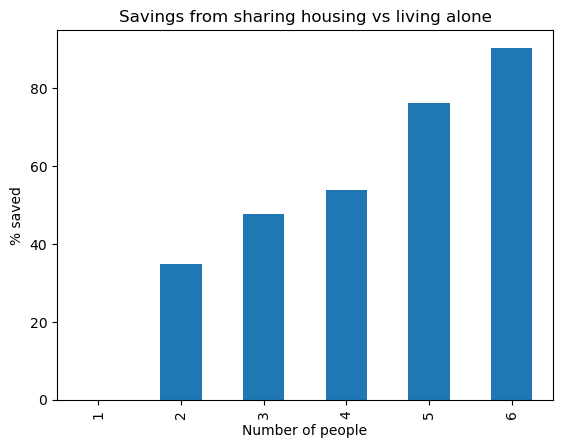

In [61]:
sharing_stats["savings_pct"].plot(kind="bar")
plt.title("Savings from sharing housing vs living alone")
plt.ylabel("% saved")
plt.xlabel("Number of people")
plt.show()

4.  
There is a strong inverse relationship between household size.   
Living alone is the most expensive option, with average monthly cost approximately 20 848 CZK.

Sharing housing significantly reduces per-person costs.   
The relationship is non-linear - the largest improvement occurs when moving from solo living to shared accommodation.   
Additional roomates continue to reduce costs, but with diminishing marginal effects.   

Strong initial cost reduction that flatten at higher household sizes.